# Feature Engineering project - 신용거래 이상탐지 데이터 다루기

is_fraud -> 사기 거래 여부를 나타내는 변수 

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold


In [127]:
data_raw = pd.read_csv('fraud.csv')

데이터는 22개 컬럼, 491134개 데이터, 결측치 없음!

In [128]:
data_raw.info()
data_raw.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  491134 non-null  object 
 1   cc_num                 491134 non-null  int64  
 2   merchant               491134 non-null  object 
 3   category               491134 non-null  object 
 4   amt                    491134 non-null  float64
 5   first                  491134 non-null  object 
 6   last                   491134 non-null  object 
 7   gender                 491134 non-null  object 
 8   street                 491134 non-null  object 
 9   city                   491134 non-null  object 
 10  state                  491134 non-null  object 
 11  zip                    491134 non-null  int64  
 12  lat                    491134 non-null  float64
 13  long                   491134 non-null  float64
 14  city_pop               491134 non-nu

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0


변수명 분석

- trans_date_trans_time  - 거래 일시   
- cc_num                 - 신용카드 번호            
- merchant               - 상점 이름
- category               - 업종 카테고리 
- amt                    - 결제 금액 
- first                  - 고객의 이름 
- last                   - 고객의 성 
- gender                 - 고객의 성별 
- street                 - 고객의 거리 주소 
- city                   - 고객의 도시 
- state                  - 고객의 주 
- zip                    - 고객의 우편번호 
- lat                    - 고객의 위도
- long                   - 고객의 경도 
- city_pop               - 고객이 사는 도시의 인구수 
- job                    - 고객의 직업
- dob                    - 고객의 생년월일
- trans_num              - 각 거래의 고유번호 
- unix_time              - 거래시간을 unix타임으로 기록 
- merch_lat              - 거래발생 상점의 위도 
- merch_long             - 거래발생 상점의 경도
- is_fraud               - 예측 목표값(사기거래 or 정상거래)


결측치 없음!

In [129]:
data_raw.isna().any()

trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

## 1-1. 사기거래 여부를 예측하는데 불필요한 컬럼 제거 
- trans_date_trans_time  - 거래 일시   
- cc_num                 - 신용카드 번호 (중요하지 않음)           
- merchant               - 상점 이름
- category               - 업종 카테고리 
- amt                    - 결제 금액 
- first                  - 고객의 이름 (중요하지 않음)
- last                   - 고객의 성 (중요하지 않음)
- gender                 - 고객의 성별 (중요하지 않음)
- street                 - 고객의 거리 주소 (중요하지 않음)
- city                   - 고객의 도시 (중요하지 않음)
- state                  - 고객의 주 (중요하지 않음)
- zip                    - 고객의 우편번호 (중요하지 않음)
- lat                    - 고객의 위도
- long                   - 고객의 경도 
- city_pop               - 고객이 사는 도시의 인구수 (중요하지 않음)
- job                    - 고객의 직업
- dob                    - 고객의 생년월일
- trans_num              - 각 거래의 고유번호 (중요하지 않음)
- unix_time              - 거래시간을 unix타임으로 기록 (중요하지 않음)
- merch_lat              - 거래발생 상점의 위도 
- merch_long             - 거래발생 상점의 경도
- is_fraud               - 예측 목표값(사기거래 or 정상거래)


정보가 중복되는 컬럼 위주 제거! + 사기거래를 파악하는데 필요하지 않는다고 생각되는 변수도 제거
- unix_time & trans_date~~,시간 정보 겹침
- 주소 데이터(위,경도로 파악 가능하니 주소정보 제거, 주소가 너무 세분화 되어있다)
- unique()고유값들 (거래번호, 카드번호, 이름과 성 등)

- 총 11개 컬럼을 제거하고 분석!

In [130]:
drop_col =['cc_num','first','last','street','city','state','zip','trans_num','unix_time','city_pop']
data = data_raw.drop(columns=drop_col)
data.head(2)

,trans_date_trans_time,merchant,category,amt,gender,lat,long,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0
1,2019-01-01 00:12:34,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,M,40.6747,-74.2239,Operational researcher,1980-12-21,40.079588,-74.848087,0


### 이상치 제거 - 금액의 로그 변환

처음엔 금액을 1500이상인 값들이 모두 이상거래가 아니길래 모두 제거하고 분석하려고함.

그러나 이상거래를 예측하려면 무조건 소액이어야 하는건 아님

예측 성능을 위해서 고액도 포함시켜야 더 다양한 금액대의 이상거래를 예측할 수 있다고 판단.

따라서 로그변환으로 안정화를 하면서 모든 금액을 포함시킴.

In [131]:
print(data['amt'].describe())
data['amt_log'] = np.log(data['amt'])
print(data['amt_log'].describe())

count    491134.000000
mean         69.050120
std         160.322867
min           1.000000
25%           8.960000
50%          42.170000
75%          80.330000
max       25086.940000
Name: amt, dtype: float64
count    491134.000000
mean          3.387064
std           1.415137
min           0.000000
25%           2.192770
50%           3.741709
75%           4.386143
max          10.130103
Name: amt_log, dtype: float64


## 1-2 최소 2개이상의 새로운 변수 생성

우선, 사기거래는 몇개가 있는가?

491134 데이터 개수 중 1244 개 존재  (약 0.25%정도, 데이터 불균형 식별)

In [132]:
print(data['is_fraud'].value_counts())
print(data.groupby('is_fraud')['merchant'].value_counts())
print(1244/491134)

is_fraud
0    489890
1      1244
Name: count, dtype: int64
is_fraud  merchant                   
0         fraud_Kilback LLC              1593
          fraud_Cormier LLC              1451
          fraud_Kuhn LLC                 1439
          fraud_Schumm PLC               1387
          fraud_Boyer PLC                1368
                                         ... 
1         fraud_Wuckert-Walter              1
          fraud_Yost, Block and Koepp       1
          fraud_Zboncak LLC                 1
          fraud_Ziemann-Waters              1
          fraud_Zulauf LLC                  1
Name: count, Length: 1190, dtype: int64
0.0025329136243876418


### 거래를 이상탐지하는데 만들 수 있는 변수1 - 시간대로 나누기 

0~11시까지는 거래량이 12~23시에 비해 약 3배정도 적음!

시간을 그룹화 해서 어느 시간대에 이상거래가 많은지 확인.
- 나머지 시간대는 최대 20회인 것에 반해 22시 ~ 03시에 100회 이상으로 이상거래량이 많음!
- 22시 ~ 03 시가 이상거래 탐지의 중요한 기점인 것 같음


In [133]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['hour'] = data['trans_date_trans_time'].dt.hour 
data['hour'].value_counts() #시간대별 거래량 파악

print(data.groupby('hour')['is_fraud'].value_counts())

data['day_night'] = data['hour'].apply(lambda x: 0 if 3 < x <= 21 else 1)
print(data['day_night'].value_counts())
print(data.groupby('day_night')['is_fraud'].value_counts())


hour  is_fraud
0     0           11400
      1             132
1     0           11410
      1             125
2     0           11512
      1             142
3     0           11380
      1             150
4     0           11348
      1              14
5     0           11478
      1              17
6     0           11385
      1               8
7     0           11558
      1              20
8     0           11522
      1              14
9     0           11551
      1              11
10    0           11475
      1              11
11    0           11412
      1               7
12    0           29449
      1               7
13    0           29374
      1              16
14    0           29223
      1               4
15    0           29683
      1               7
16    0           29619
      1              10
17    0           29405
      1               4
18    0           29507
      1               9
19    0           29171
      1              12
20    0           29179
 

### 거래를 이상탐지하는데 만들 수 있는 변수2 - 금액을 이용하기

금액이 크면 이상거래가 많을 수 도 있음!
- 100달러 이상(e^4.6) 거래가 913회로 대부분을 차지함! (3분위수에 가까운 값보다 크면 높은 금액으로 설정)

In [134]:
np.exp(4.6)

np.float64(99.48431564193378)

In [135]:
print(data[data['amt_log'] >= 4.6]['is_fraud'].value_counts())
data['is_high_amt'] = (data['amt_log'] >= 4.6).astype(int)
display(data[['trans_date_trans_time','amt_log', 'is_high_amt', 'day_night']].head())
data.head()

is_fraud
0    88599
1      913
Name: count, dtype: int64


,trans_date_trans_time,amt_log,is_high_amt,day_night
0,2019-01-01 00:00:44,4.674976,1,1
1,2019-01-01 00:12:34,3.800197,0,1
2,2019-01-01 00:17:16,3.834710,0,1
3,2019-01-01 00:20:15,4.160288,0,1
4,2019-01-01 00:23:41,3.241811,0,1


,trans_date_trans_time,merchant,category,amt,gender,lat,long,job,dob,merch_lat,merch_long,is_fraud,amt_log,hour,day_night,is_high_amt
0,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,4.674976,0,1,1
1,2019-01-01 00:12:34,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,M,40.6747,-74.2239,Operational researcher,1980-12-21,40.079588,-74.848087,0,3.800197,0,1,0
2,2019-01-01 00:17:16,fraud_Kling-Grant,grocery_net,46.28,F,40.6152,-74.4150,Leisure centre manager,1974-07-19,40.021888,-74.228188,0,3.834710,0,1,0
3,2019-01-01 00:20:15,fraud_Deckow-O'Conner,grocery_pos,64.09,M,42.2203,-83.3583,Police officer,1971-11-05,42.360426,-83.552316,0,4.160288,0,1,0
4,2019-01-01 00:23:41,fraud_Balistreri-Nader,misc_pos,25.58,F,30.4066,-91.1468,"Designer, furniture",1977-02-22,29.737426,-90.853194,0,3.241811,0,1,0


### 거래를 이상탐지하는데 만들 수 있는 변수3 - 고객의 나이?

고객의 나이에 따라서 이상거래를 할 수도 있음! 

보이스피싱이나 사기피해자에 고령자가 많다고 들었음.

<Axes: xlabel='age', ylabel='Count'>

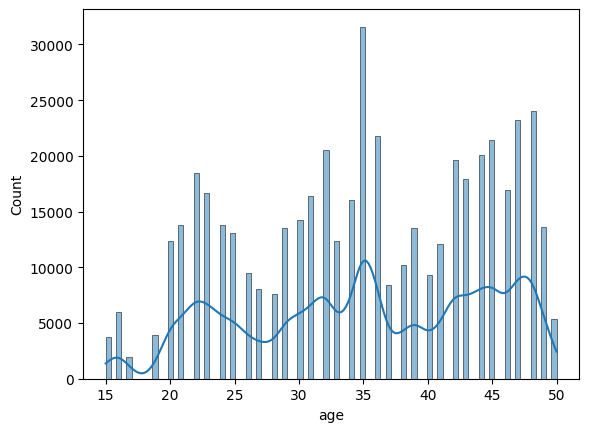

In [136]:
data['dob'] = pd.to_datetime(data['dob'])
data['dob_year'] = data['dob'].dt.year 
data['age'] = data['trans_date_trans_time'].dt.year - data['dob'].dt.year #나이 = 결제 시점 - 생년월일
sns.histplot(data['age'],kde=True)

## 2. EDA

### 이상거래 vs 업종 카테고리

- grocery_pos, shopping_net 업종이 200회 이상으로 많다? -> 이상거래의 주타깃일 것이다.

In [143]:
pd.crosstab(data['is_fraud'],data['category'])

category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
is_fraud,,,,,,,,,,,,,,
0,33566,35918,45928,24478,42506,31375,43268,40227,25070,32354,35455,38937,48211,12597
1,53,62,101,8,216,40,72,68,109,57,58,242,134,24


### 이상거래 vs 성별

- 여자가 남자에 비해 두 배 정도 이상거래가 존재한다!

In [137]:
pd.crosstab(data['is_fraud'],data['gender'])

gender,F,M
is_fraud,,
0,351597,138293
1,848,396


### 이상거래 vs 고객의 나이 

- 데이터의 불균형이 심하기 때문에 kdeplot을 사용! 밀도 기반이기 때문.

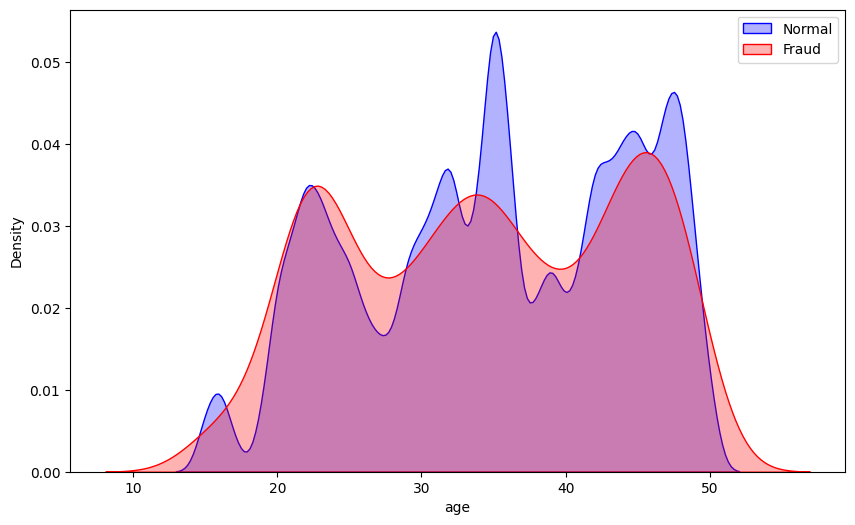

In [138]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data[data['is_fraud'] == 0]['age'], label='Normal', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=data[data['is_fraud'] == 1]['age'], label='Fraud', fill=True, color='red', alpha=0.3)
plt.legend()

### 이상거래 vs 결제 금액 

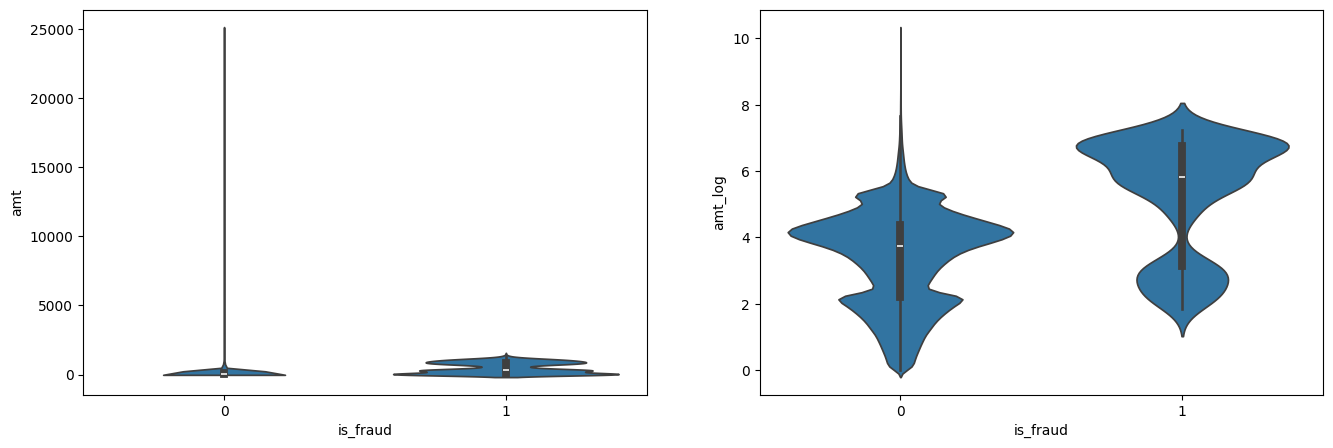

In [139]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=data, x='is_fraud', y=data['amt'],ax=ax[0])
sns.violinplot(data=data, x='is_fraud', y=data['amt_log'],ax=ax[1])
plt.show()

그냥 금액으로 violin plot을 그리면 파악하기가 힘듦 (금액에 대해서 편차가 매우 큼)

로그변환한 amt_log로 보면, 금액이 높을수록 확실히 이상거래일 수 있을 것 같다고 판단

### 지리정보 시각화 

- 위도 경도를 금액별로 시각화 + 미국전역을 

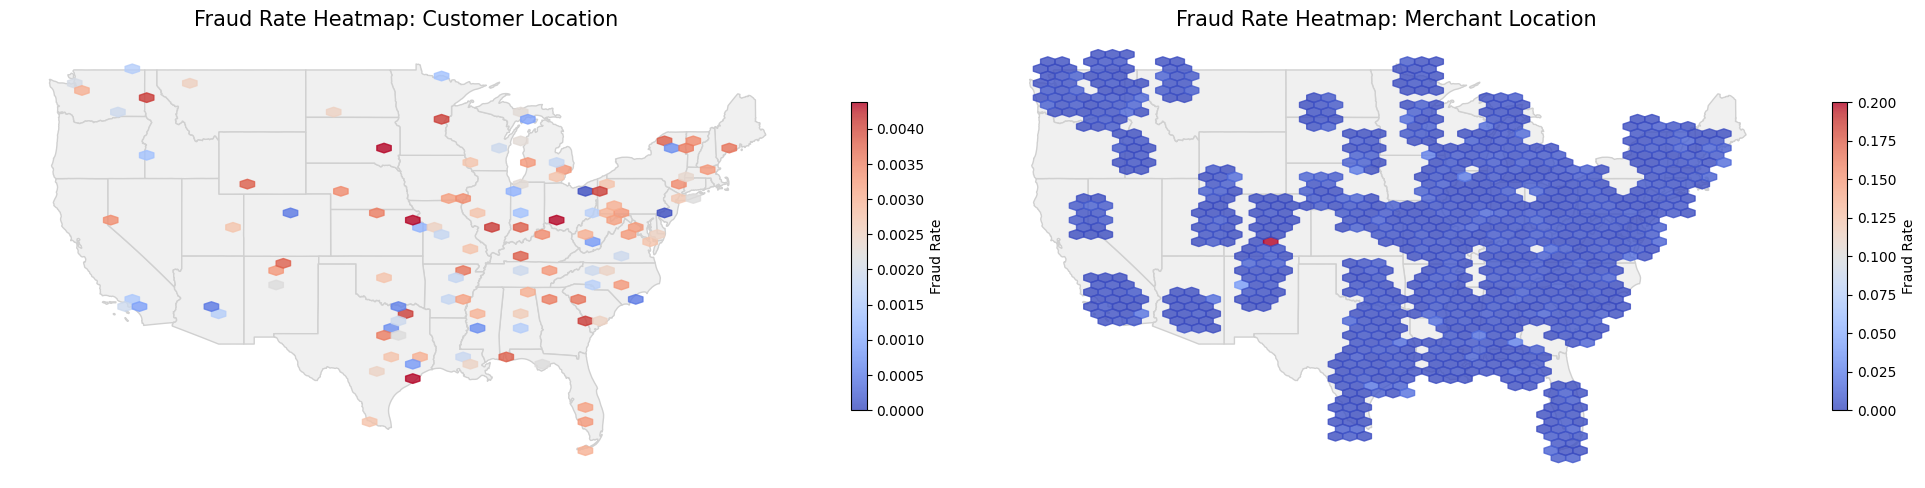

In [140]:
import geopandas as gpd

url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
usa_full = gpd.read_file(url)
usa = usa_full[~usa_full['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI', 'AS', 'MP'])]

# 2. 반복할 대상 정의 (컬럼명 쌍)
locations = [
    {'lon': 'long', 'lat': 'lat', 'title': 'Customer Location'},
    {'lon': 'merch_long', 'lat': 'merch_lat', 'title': 'Merchant Location'}
]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, loc in enumerate(locations):
    ax = axes[i]
    usa.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0')
    hb = ax.hexbin(
        data[loc['lon']], data[loc['lat']], 
        C=data['is_fraud'], 
        gridsize=50, 
        cmap='coolwarm', 
        reduce_C_function=np.mean,
        extent=[-125, -67, 24, 50],
        alpha=0.8
    )
    ax.set_axis_off()
    ax.set_title(f'Fraud Rate Heatmap: {loc["title"]}', fontsize=15)
    cb = fig.colorbar(hb, ax=ax, shrink=0.4)
    cb.set_label('Fraud Rate')

plt.tight_layout()
plt.show()

고객의 위치 지도로 보았을때 이상거래는 중부와 동부에 걸쳐서 많이 분포되어 있음. 서부로 갈수록 빈도가 확연히 줄어듦.

상점의 위치 지도로 보았을 때 이상거래가 CO(콜로라도)주의 상점에 이상거래 확률이 높은 곳이 존재함! 그렇지만 너무 빈도가 낮음..

------

데이터는 매우 불균형함. 이상거래가 전체의 0.25% 이기 때문에 그냥 무작위로 추출해도 Accuracy가 99.75% 로 의미가 없음!

이상거래를 예측하려면 모델의 정확도보단 재현율(Recall)에 초점을 맞춰야함. 랜덤포레스트 사용하기!

### 상관분석

- 상점 vs 고객 위치는 거의 동일한 정보를 담고 있다고 보면 된다. 나머지는 상관관계가 뚜렷하지 않음!

<Axes: >

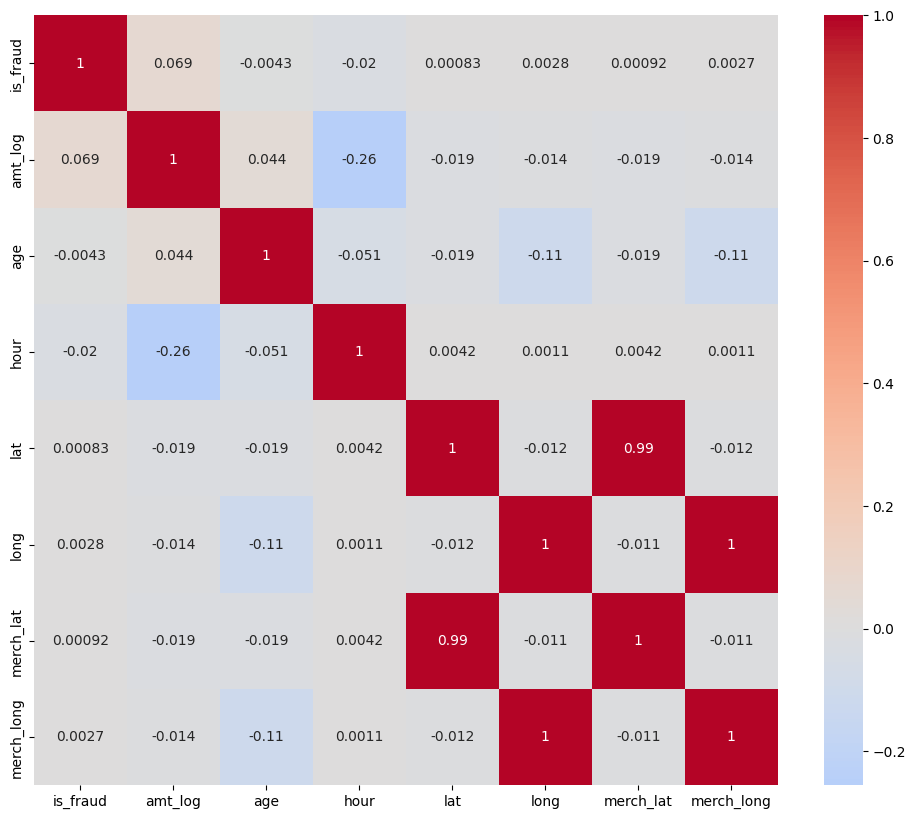

In [141]:
corr_features = [
    'is_fraud', 'amt_log','age', 'hour', 
    'lat', 'long', 'merch_lat', 'merch_long']
corr_matrix = data[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0)


## 모델 학습(RandomForest)

In [146]:
feature_sets = [
    ['amt', 'lat', 'long', 'dob_year', 'hour'], #살짝 정제된 raw데이터
    ['amt_log', 'lat', 'long', 'day_night', 'age'] #사용하는 features    
]
for i, features in enumerate(feature_sets):
    X = data[features]
    y = data['is_fraud']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,class_weight='balanced')
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



[[97631   347]
 [  116   133]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.28      0.53      0.36       249

    accuracy                           1.00     98227
   macro avg       0.64      0.77      0.68     98227
weighted avg       1.00      1.00      1.00     98227

[[92726  5252]
 [   87   162]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     97978
           1       0.03      0.65      0.06       249

    accuracy                           0.95     98227
   macro avg       0.51      0.80      0.51     98227
weighted avg       1.00      0.95      0.97     98227



raw 데이터에서 중복된 변수를 제거한 모델은 재현율 0.53으로 비교적 낮았지만

feature selection을 통한 모델은 재현율(Recall)이 약 65% 즉, 이상 거래를 캐치할 확률이 65% 정도로 성능 향상을 보였음. 

다만 정확도를 너무 많이 희생했던건 아쉬움.

데이터 불균형이 너무 심해서 지리정보 시각화 정보가 활용도가 많이 낮았던 점도 아쉬움.
